# Community members

# Active members of the benchmarking effort

---


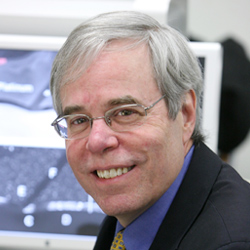
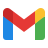
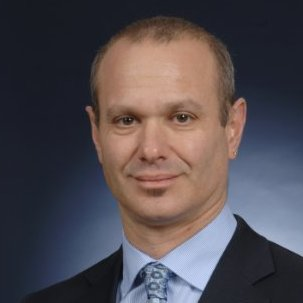
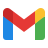
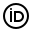
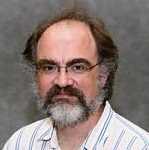
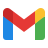
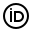
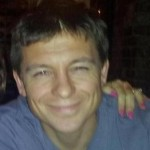
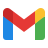
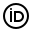

In [1]:
import base64
import os
import pandas as pd
from IPython.display import HTML, display

# Load the data
df = pd.read_csv('./people.csv')

# Helper function to convert local images to Base64
def get_base64_image(image_path):
    try:
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")
    except FileNotFoundError:
        # Fallback empty pixel if an image is missing so the script doesn't crash
        return "R0lGODlhAQABAIAAAAAAAP///yH5BAEAAAAALAAAAAABAAEAAAIBRAA7"

# Pre-load shared icons once (saves processing time during the loop)
gmail_icon_base64 = get_base64_image("../images/gmail.png")
github_icon_base64 = get_base64_image("../images/github.png")
orcid_icon_base64 = get_base64_image("../images/orcid.png")

# Initialize an empty string to hold all cards HTML
all_cards_html = ""

import textwrap

# Loop through every row in the dataframe
for index, person in df.iterrows():
    # Resolve the main image path dynamically
    if pd.notna(person["images"]):
        main_img_path = os.path.join("../images", os.path.basename(person["images"]))
        main_img_base64 = get_base64_image(main_img_path)
    else:
        main_img_base64 = "R0lGODlhAQABAIAAAAAAAP///yH5BAEAAAAALAAAAAABAAEAAAIBRAA7"

    # Build the HTML snippets for social links conditionally (hides them if empty in CSV)
    email_html = f'<p><img src="data:image/png;base64,{gmail_icon_base64}" alt="Gmail" style="width: 16px; vertical-align: middle;"> {person["email"]}</p>' if pd.notna(person["email"]) else ""
    github_html = f'<p><img src="data:image/png;base64,{github_icon_base64}" alt="GitHub" style="width: 16px; vertical-align: middle;"> {person["github"]}</p>' if pd.notna(person["github"]) else ""
    orcid_html = f'<p><img src="data:image/png;base64,{orcid_icon_base64}" alt="ORCID" style="width: 16px; vertical-align: middle;"> {person["orcid"]}</p>' if pd.notna(person["orcid"]) else ""
    
    name = person["name"] if pd.notna(person["name"]) else "Unknown Name"
    description = person["description"] if pd.notna(person["description"]) else ""
    
    # Wrap description to 45 characters per line
    wrapped_description = textwrap.fill(description, width=45)
    # Convert line breaks to HTML line breaks
    description_html = wrapped_description.replace("\n", "<br>")

    # Append this person's card to the master HTML string
    all_cards_html += f'''
    <div class="person-card" style="margin-bottom: 20px;">
        <img src="data:image/jpeg;base64,{main_img_base64}" alt="{name}">
        <div class="inner-card">
            <p><strong>{name}</strong></p>
            <p>{description_html}</p>
            {email_html}
            {github_html}
            {orcid_html}
        </div>
    </div>
    '''

# Display all cards at once in Jupyter Book
display(HTML(all_cards_html))